**TASK 1:Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**Step 2: Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


**Step 3: Load Dataset**

In [3]:
df = pd.read_csv('StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Step 4: Check Dataset Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


**Step 5: Encode Categorical Columns**

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


**Step 6: Select Features and Target**

In [9]:
y = df['math score']
X = df.drop('math score', axis=1)

**Step 7: Split Training and Testing Data**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Step 8: Linear Regression Model**

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test, y_pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("R2 Score:",
      r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 4.1301450780040545
RMSE: 5.317450940660133
R2 Score: 0.8838026201112223


**Step 9: Decision Tree Model**

In [13]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [14]:
print("Decision Tree")

print("MAE:",
      mean_absolute_error(y_test, y_pred_dt))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_dt)))

print("R2 Score:",
      r2_score(y_test, y_pred_dt))

Decision Tree
MAE: 6.0
RMSE: 7.801281945936834
R2 Score: 0.7498956186117769


**Step 10: Random Forest Model**

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [16]:
print("Random Forest")

print("MAE:",
      mean_absolute_error(y_test, y_pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("R2 Score:",
      r2_score(y_test, y_pred_rf))

Random Forest
MAE: 4.70082380952381
RMSE: 6.065824068029948
R2 Score: 0.8487940184356789


**Step 11: Compare Model Performance**

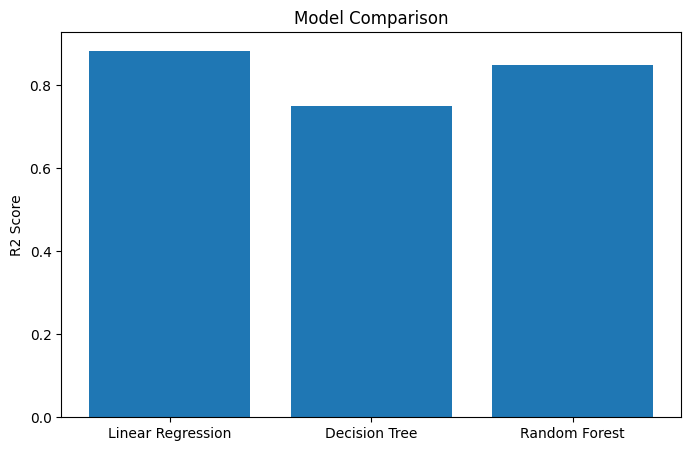

In [17]:
models = ['Linear Regression',
          'Decision Tree',
          'Random Forest']

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.ylabel('R2 Score')
plt.title('Model Comparison')
plt.show()

**Step 12: Actual vs Predicted Graph**

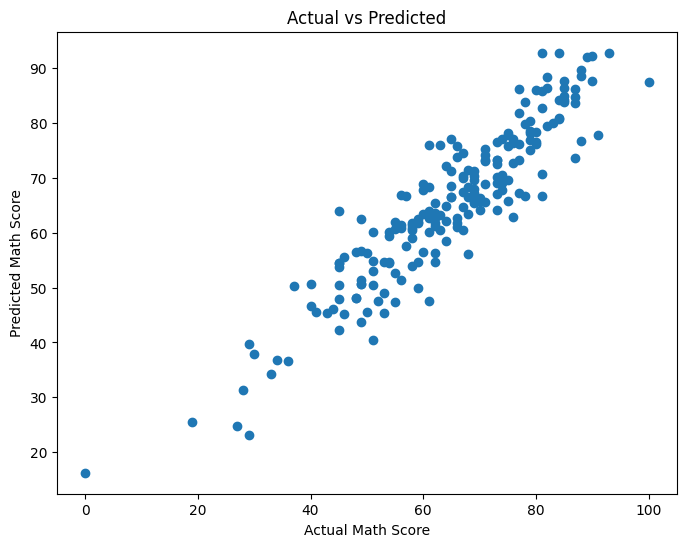

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")

plt.title("Actual vs Predicted")

plt.show()

**Step 13: Feature Importance (Random Forest)**

In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                       Feature  Importance
5                reading score    0.565059
6                writing score    0.236134
0                       gender    0.120868
1               race/ethnicity    0.026877
2  parental level of education    0.023319
3                        lunch    0.016024
4      test preparation course    0.011719


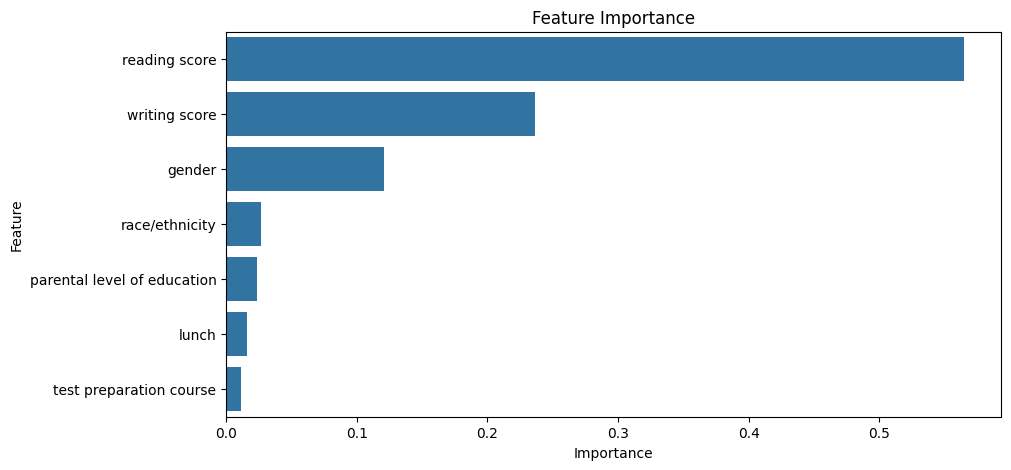

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()